<a href="https://colab.research.google.com/github/Atharva0611/machine-learning/blob/main/TVlinearregressoon%2Cipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
df.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [ ]:
df.shape

(200, 4)

In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
df.duplicated().sum()

np.int64(0)

calculate correaltion first

In [ ]:
#correlation
corr=df.corr()
corr

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


<Axes: >

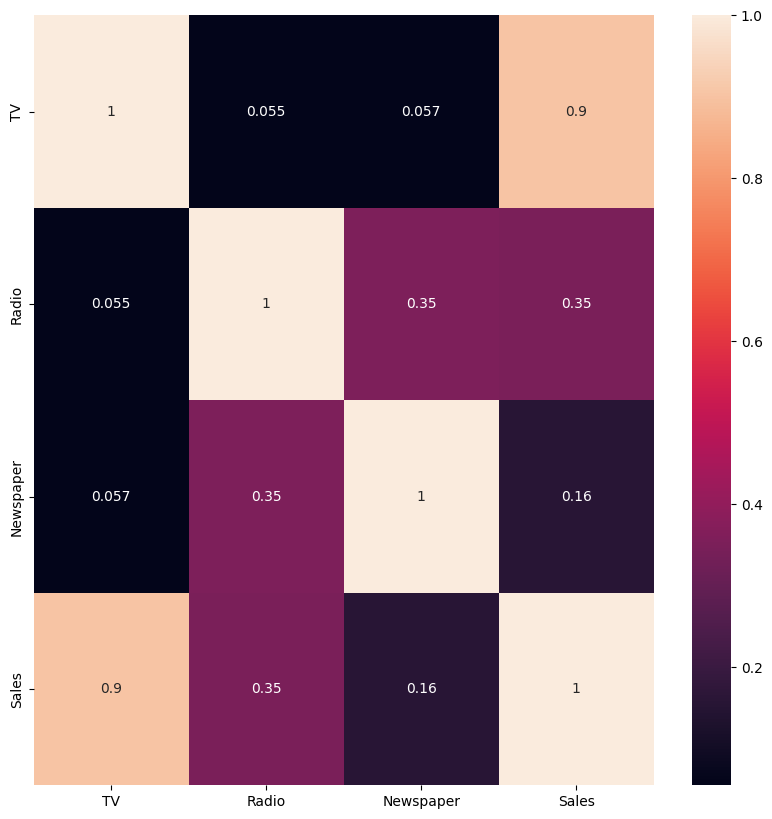

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot=True)


<Axes: title={'center': 'correlation'}>

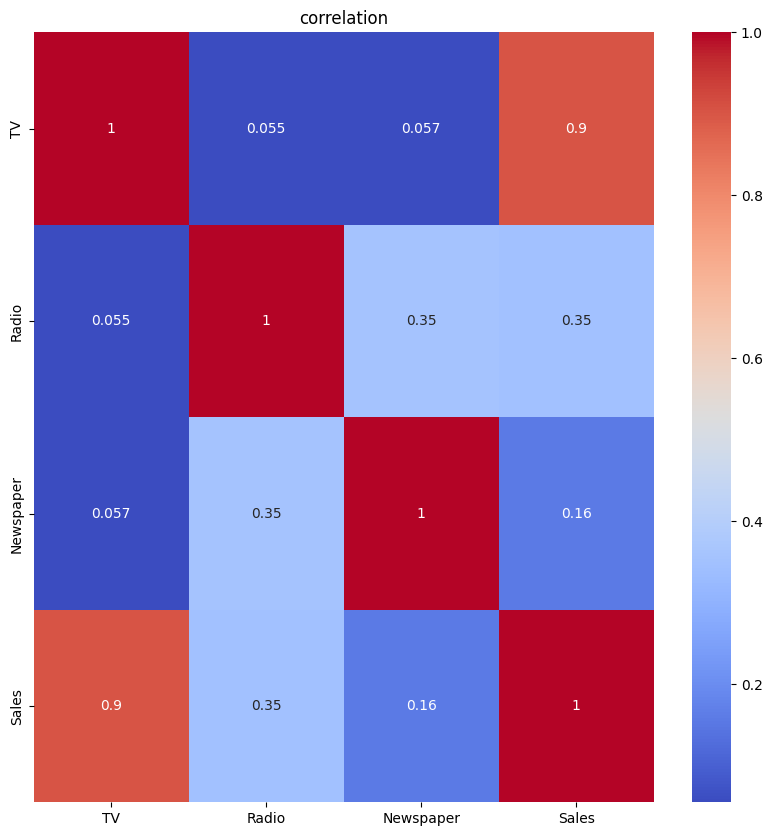

In [ ]:
plt.figure(figsize=(10,10))
plt.title('correlation')

sns.heatmap(corr,annot=True,cmap='coolwarm')


In [ ]:
X = df['TV']
y = df['Sales']

training testing and spiliting the dataset

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 100)


call model from sklearn libraray

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lm=LinearRegression()

In [ ]:
lm.fit(X_train.values.reshape(-1, 1), y_train)

LinearRegression()

In [ ]:
lm.intercept_

np.float64(6.948683200001357)

In [ ]:
predictions = lm.predict(X_test.values.reshape(-1, 1))
print("Predictions:")
display(predictions)

Predictions:


array([ 7.37414007, 19.94148154, 14.32326899, 18.82329361, 20.13239168,
       18.2287449 , 14.54145201, 17.72692398, 18.75238413, 18.77420243,
       13.34144544, 19.46693349, 10.01415451, 17.1923756 , 11.70507285,
       12.08689312, 15.11418241, 16.23237035, 15.8669138 , 13.1068987 ,
       18.65965635, 14.00690363, 17.60692332, 16.60328147, 17.03419291,
       18.96511257, 18.93783969, 11.05597839, 17.03419291, 13.66326538,
       10.6796127 , 10.71234015, 13.5487193 , 17.22510305,  9.67597085,
       13.52144643, 12.25053038, 16.13418799, 19.07965865, 17.48692266,
       18.69783838, 16.53237199, 15.92145955, 18.86693021, 13.5050827 ,
       11.84143724,  7.87050642, 20.51966653, 10.79961336,  9.03233096,
       17.99419817, 16.29237067, 11.04506924, 14.09963141, 18.44147334,
        9.3759692 ,  7.88687015,  8.34505447, 17.72692398, 11.62325422])

In [ ]:
coeff=pd.DataFrame(lm.coef_.T, index=[X.name], columns=["coefficient"])
coeff

,coefficient
TV,0.054546


In [ ]:
predictions = lm.predict(X_test.values.reshape(-1, 1))

##metrices

from sklearn import metrics

import numpy as np
print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('MSE:', metrics.mean_squared_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))

MAE: 1.6480589869746525
MSE: 4.077556371826948
RMSE: 2.019296008966231


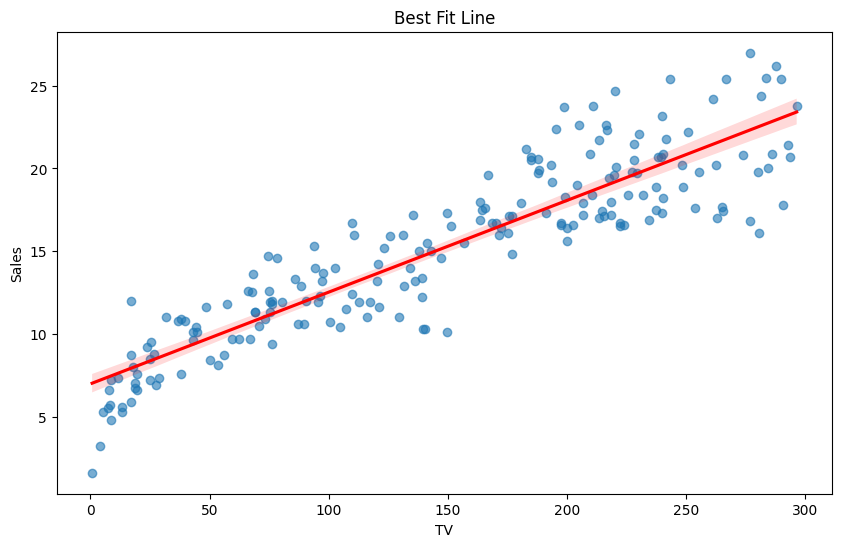

In [ ]:
# Best fit Line graph

import seaborn as sns

plt.figure(figsize= (10,6))

sns.regplot(data= df , x='TV', y ='Sales',

           scatter_kws= {'alpha':0.6},line_kws={'color':'Red'})

plt.title('Best Fit Line')

plt.show()

In [ ]:
#formula

intercept=lm.intercept_
coeff=lm.coef_
print(intercept)


6.948683200001357


In [ ]:
#random values
# The model was trained on 'TV' advertising only, so it expects a single feature for prediction.
# Let's assume we want to predict sales for a TV advertising budget of 150.
new_tv_budget = [[150]] # Provide a single feature as a 2D array
predicated_val = lm.predict(new_tv_budget)
print(f"Predicted Sales for TV budget of 150: {predicated_val[0]:.2f}")

Predicted Sales for TV budget of 150: 15.13
